<a href="https://colab.research.google.com/github/praveena1149/project3/blob/main/project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score,recall_score,f1_score


# Upload the CSV file
uploaded = files.upload()

df=pd.read_csv('jobprediction.csv')

df['internship_experience'] = df['internship_experience'].replace([' ', '', 'NA', 'None'], np.nan)
df['company_tier'] = df['company_tier'].replace([' ', '', 'NA', 'None'], np.nan)

df['internship_experience'] = df['internship_experience'].str.strip()
df['company_tier'] = df['company_tier'].str.strip()

#filling null values
# for numeric columns
num_cols=df.select_dtypes(include=['int64','float64']).columns
num_imputer=SimpleImputer(strategy='median')
df[num_cols]=num_imputer.fit_transform(df[num_cols])


#for categorical columns
cat_cols=df.select_dtypes(include='object').columns
cat_imputer=SimpleImputer(strategy='most_frequent')
df[cat_cols]=pd.DataFrame(cat_imputer.fit_transform(df[cat_cols]),columns=cat_cols,index=df.index)


# changing datatype
df['certifications_count']=df['certifications_count'].astype(int)
df['notice_period_days']=df['notice_period_days'].astype(int)
df['employment_gap_months']=df['employment_gap_months'].astype(int)
df['age_years']=df['age_years'].astype(int)
df['years_of_experience']=df['years_of_experience'].astype(int)

# Correcting inconsistent categorical labels

gender_mapping={'Male':'Male','Female':'Female','male':'Male','female':'Female'}
df['gender']=df['gender'].map(gender_mapping)

intership_mapping={'Yes':'Yes','No':'No','yes':'Yes','no':'No'}
df['internship_experience']=df['internship_experience'].map(intership_mapping)

company_tier_mapping={'Tier 1':'Tier 1','Tier 2':'Tier 2','Tier 3':'Tier 3'}
df['company_tier']=df['company_tier'].map(company_tier_mapping)

# removing duplicate rows

df=df.drop_duplicates()

# detection of outliers
for col in num_cols:
    Q1 = df[col].quantile(0.25)   # First quartile (25%)
    Q3 = df[col].quantile(0.75)   # Third quartile (75%)
    IQR = Q3 - Q1                      # Interquartile Range

    lower_bound = Q1 - 1.5 * IQR       # Lower limit for outliers
    upper_bound = Q3 + 1.5 * IQR       # Upper limit for outliers

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f" Column: {col} —  {len(outliers)} outliers")

    #correcting outlires
# Select numeric columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Capping the outliers
    df[col] = df[col].apply(lambda x: lower if x < lower else upper if x > upper else x)

print('outliers handled successfully')

# feature engineering
# 1.Experience category (Fresher / Junior / Senior)

def experience_category(x):
    if x == 0:
        return "Fresher"
    elif x <= 2:
        return "Junior"
    else:
        return "Senior"

df['experience_category'] = df['years_of_experience'].apply(experience_category)

# 2.Academic performance bands

def academic_band(x):
    if x < 60:
        return "Low"
    elif x < 75:
        return "Medium"
    else:
        return "High"

df['academic_performance_band'] = df['degree_percentage'].apply(academic_band)

# 3.Skills match level (Low / Medium / High)

def skills_match_level(x):
    if x <=60.00:
        return "Low"
    elif x <= 75.00:
        return "Medium"
    else:
        return "High"

df['skills_match_level']=df['skills_match_percentage'].apply(skills_match_level)

# 4.Interview performance category

# Create overall interview score
df['interview_score'] = (
    df['technical_score'] +
    df['aptitude_score'] +
    df['communication_score']
) / 3

def interview_category(x):
    if x < 50:
        return "Poor"
    elif x < 70:
        return "Average"
    else:
        return "Excellent"

df['interview_performance_category'] = df['interview_score'].apply(interview_category)

# 5.Placement probability score
# Calculate interview score
df['interview_score'] = (
    df['technical_score'] +
    df['aptitude_score'] +
    df['communication_score']
) / 3

# Calculate placement probability score
df['placement_probability_score'] = (
    0.4 * df['degree_percentage'] +
    0.3 * df['skills_match_percentage'] +
    0.3 * df['interview_score']
)

df

Saving jobprediction.csv to jobprediction (6).csv
 Column: age_years —  0 outliers
 Column: ssc_percentage —  268 outliers
 Column: hsc_percentage —  517 outliers
 Column: degree_percentage —  363 outliers
 Column: technical_score —  0 outliers
 Column: aptitude_score —  181 outliers
 Column: communication_score —  161 outliers
 Column: skills_match_percentage —  0 outliers
 Column: certifications_count —  2699 outliers
 Column: years_of_experience —  0 outliers
 Column: previous_ctc_lpa —  179 outliers
 Column: expected_ctc_lpa —  296 outliers
 Column: notice_period_days —  2476 outliers
 Column: employment_gap_months —  1520 outliers
outliers handled successfully


,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,layoff_history,employment_gap_months,relocation_willingness,status,experience_category,academic_performance_band,skills_match_level,interview_score,interview_performance_category,placement_probability_score
0,27,Male,65.061656,83.842578,75.856526,Computer Science,58.221909,89.566305,64.474484,79.548913,...,No,15.0,Not Willing,Not Placed,Junior,High,High,70.754233,Excellent,75.433554
1,24,Male,67.885626,64.973305,73.093588,Electronics,71.927978,54.591971,61.077306,73.316134,...,No,0.0,Not Willing,Not Placed,Fresher,Medium,Medium,62.532418,Average,69.992001
2,33,Female,73.892471,68.834121,90.196460,Information Technology,72.445041,58.587088,79.494739,75.466980,...,No,3.0,Not Willing,Placed,Junior,High,High,70.175622,Excellent,79.771365
3,31,Male,74.145568,76.255126,75.586731,Mechanical,78.855676,61.022065,53.740386,73.676449,...,Yes,6.0,Willing,Not Placed,Fresher,High,Medium,64.539376,Average,71.699440
4,28,Male,60.475937,65.786336,80.801010,Information Technology,68.286776,65.713731,61.438314,88.994847,...,No,3.0,Willing,Not Placed,Fresher,High,High,65.146274,Average,78.562740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,29,Female,76.382971,82.705920,81.790211,Electronics,71.955587,74.280744,65.613587,61.997596,...,No,6.0,Willing,Not Placed,Junior,High,Medium,70.616639,Excellent,72.500355
49996,32,Female,80.029965,68.803782,69.178840,Mechanical,53.488972,51.796635,75.373337,77.767081,...,No,0.0,Willing,Not Placed,Fresher,Medium,High,60.219648,Average,69.067555
49997,28,Male,61.801411,69.771590,79.777937,Mechanical,60.530457,40.000000,54.851899,54.749371,...,No,3.0,Willing,Not Placed,Fresher,High,Low,51.794119,Average,63.874222
49998,34,Male,71.811897,76.840708,86.809844,Others,67.611868,44.373600,69.899354,92.333175,...,No,0.0,Not Willing,Not Placed,Fresher,High,High,60.628274,Average,80.612372


In [ ]:
df_csv=df.to_csv('project3_cleaned.csv',index=False)

**Exploratory data analysis**

/tmp/ipykernel_878/1789666212.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='status', y='interview_score', data=df,palette=colors)


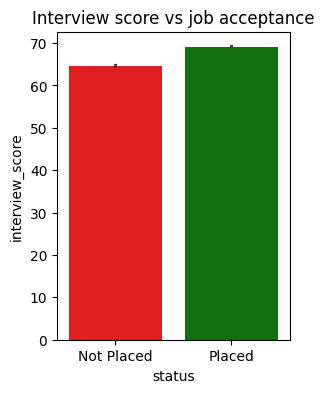

In [ ]:
# 1.Interview score vs job acceptance
# Calculate interview score
df['interview_score'] = (
    df['technical_score'] +
    df['aptitude_score'] +
    df['communication_score']) / 3
df.groupby('status')['interview_score'].mean()
plt.figure(figsize=(3, 4))
plt.title('Interview score vs job acceptance')
colors=['red','green']
sns.barplot(x='status', y='interview_score', data=df,palette=colors)
plt.show()

In [ ]:
# Insights
#   1.persons who got below 65% as interview score is not placed.
#   2.persons who got above 65% as interview score got placed.

/tmp/ipykernel_194/3058257825.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='status', y='skills_match_percentage', data=df,palette=colors)


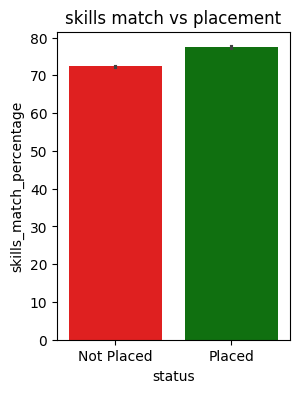

In [ ]:
#2.Skills match percentage impact on placement

plt.figure(figsize=(3, 4))
colors=['red','green']
plt.title('skills match vs placement')
sns.barplot(x='status', y='skills_match_percentage', data=df,palette=colors)
plt.show()

In [ ]:
# Insights
#   1.persons who got below 75% in skills match percentage is not placed.
#   2.persons who got above 75% in  skills match percentage got placed.

/tmp/ipykernel_194/2224921765.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x='status', y='company_tier', data=df,palette=colors)


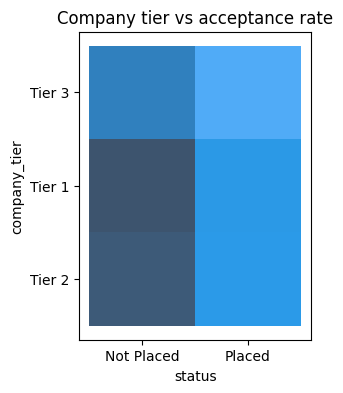

In [ ]:
# 3.Company tier vs acceptance rate

plt.figure(figsize=(3, 4))
colors=['red','green']
plt.title('Company tier vs acceptance rate')
sns.histplot(x='status', y='company_tier', data=df,palette=colors)
plt.show()

In [ ]:
# Insights
# Some candidates were not placed even for Tier-2 and Tier-3 companies,
# meaning other factors like skills, interview score, or experience might influence placement.

/tmp/ipykernel_194/2696805768.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='years_of_experience', y='placement_probability_score', data=df,palette=colors)


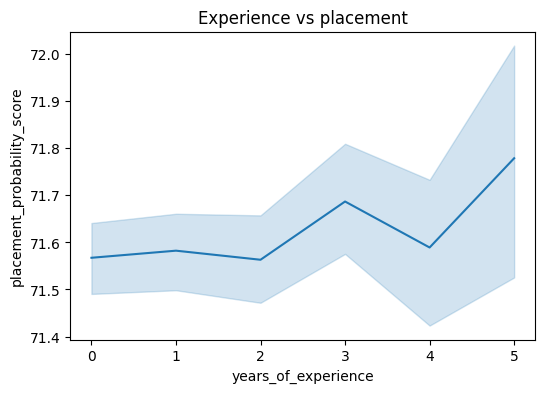

In [ ]:
# 4.Experience vs placement probability

plt.figure(figsize=(6, 4))
colors=['red','green']
plt.title('Experience vs placement')
sns.lineplot(x='years_of_experience', y='placement_probability_score', data=df,palette=colors)
plt.show()

In [ ]:
#Insights:
#   1.For years of experience upto 2 years the probability score remains the same.
#   2.for experience more than 2 years the placement probability score is slightly getting increased.


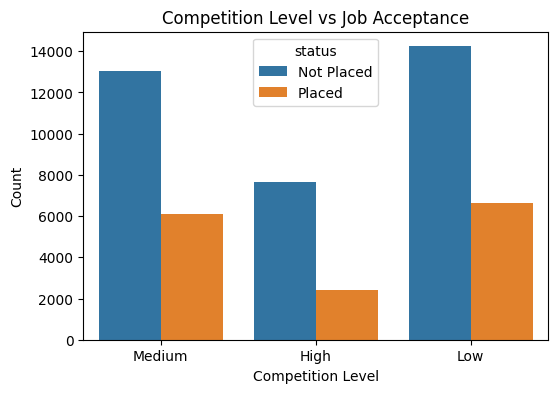

In [ ]:
# 5.Competition level vs job acceptance

plt.figure(figsize=(6,4))
sns.countplot(x='competition_level', hue='status', data=df)
plt.title("Competition Level vs Job Acceptance")
plt.xlabel("Competition Level")
plt.ylabel("Count")
plt.show()



In [ ]:
#Insights:
#    1.when the competition level is high,only fewer persons got placed.
#    2.when the competition level is low,more persons are likely got placed.
#    3.for the competition level is medium also,more persons are got placed.

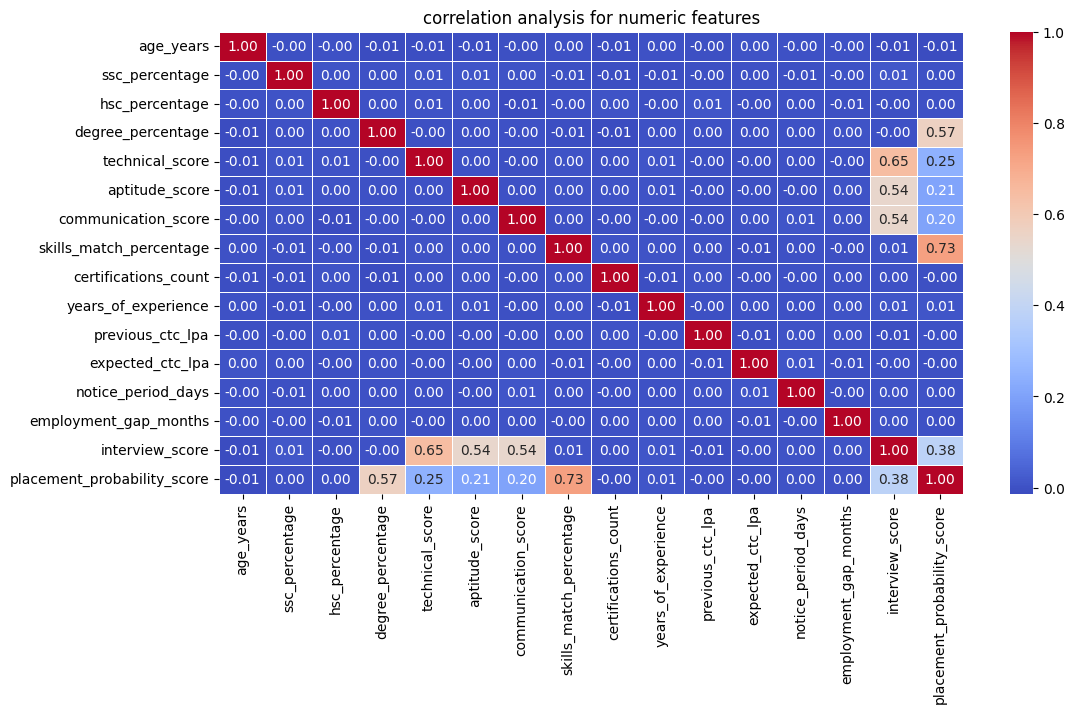

In [ ]:
# 6.Correlation analysis among numeric features

numeric = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric.corr()

plt.figure(figsize=(12,6))
plt.title('correlation analysis for numeric features')
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.show()

In [ ]:
# Insights:
# Most of the numeric features has no correlation.
# but some fetures like skills match percentage and placement probability score have have 0.73 correlation.
# features technical score and interview score have 0.65 correlation.

In [ ]:
# logistic regression
# accuracy= 0.8696
# precision score= 0.8080949057920447
# recall score= 0.7543973941368078
# f1 score= 0.7803234501347709

In [ ]:
# knn algorithm
# accuracy= 0.818354114713217
# precision score= 0.7306025994486018
# recall score= 0.6199866310160428
# f1 score= 0.6707647803290544

In [ ]:
# i got more accuracy in Randomforest algorithm compared to other algorithms.
# so i freeze Randomforest algorithm for this dataset.

In [ ]:
#label encoding for categorical columns using loop

cat_cols=df.select_dtypes(include='object').columns
le=LabelEncoder()
for col in cat_cols:
 df[col]=le.fit_transform(df[col])

In [ ]:

# random forest algorithm
# train and test split

X=df.drop(columns=['status'])
y=df['status']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# The target feature(status) is imbalanced.so we need to do oversampling

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

#scaling

# Feature scaling for numerical columns
scaler=StandardScaler()
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

#model
rfc=RandomForestClassifier(n_estimators=1500,max_depth=17)
rfc.fit(X_train,y_train)
y_prediction=rfc.predict(X_test)
print('accuracy=',accuracy_score(y_test,y_prediction))
print('precision score=',precision_score(y_test,y_prediction))
print('recall score=',recall_score(y_test,y_prediction))
print('f1 score=',f1_score(y_test,y_prediction))

accuracy= 0.8877
precision score= 0.8538713195201745
recall score= 0.7651465798045602
f1 score= 0.8070778216801237


In [ ]:
# saving the model
import pickle
with open('model2.pkl','wb') as f:
  pickle.dump(rfc,f)

# downloading the model
from google.colab import files
files.download("model2.pkl")
pickle.dump(scaler, open("scaler2.pkl", "wb"))
pickle.dump(le, open("encoder2.pkl", "wb"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Analyst tasks(EDA & ML Analytics)**

/tmp/ipykernel_194/414475446.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='status',y='academic_score',data=df,palette=colors)


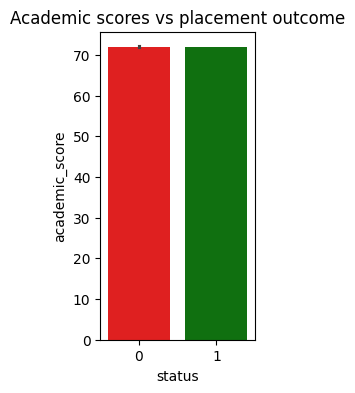

In [ ]:
# 1. Academic scores vs placement outcome

df['academic_score']= (df['degree_percentage']+
                       df['ssc_percentage']+
                       df['hsc_percentage'])/3

plt.figure(figsize=(2,4))
plt.title('Academic scores vs placement outcome')
colors=['red','green']
sns.barplot(x='status',y='academic_score',data=df,palette=colors)
plt.show()



In [ ]:
# Insights:
#    1.This graph clearly shows that, academic score doesnt strongly influence placement.
#    2.since there is no difference , placement likely depends :
#              1.experience
#              2.Interview performance
#              3.Internships experience

<Axes: title={'center': 'Skills match vs interview performance'}, xlabel='skills_match_level', ylabel='interview_score'>

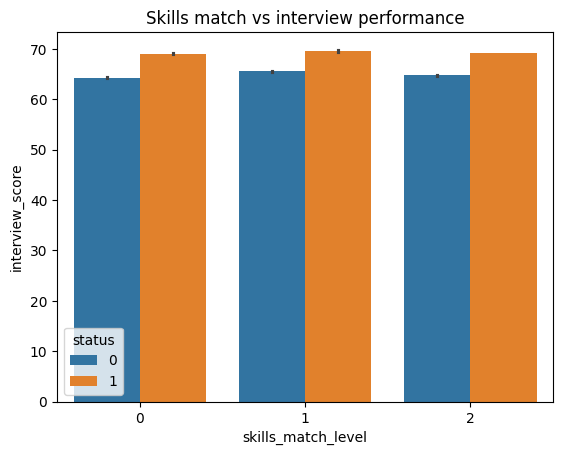

In [ ]:
# 2.Skills match vs interview performance
# Calculate interview score
df['interview_score'] = (
    df['technical_score'] +
    df['aptitude_score'] +
    df['communication_score']
) / 3
plt.title('Skills match vs interview performance')
sns.barplot(x='skills_match_level', y='interview_score', data=df, hue='status', legend=True)

In [ ]:
#Insights:
#    1.Interview score is strongly plays a major part in placement.
#    2.but the increase for placed persons is not very high comapred to not placed persons.
#    3.This indicates,Interview performance is not only based on skills Communication / confidence also matters.

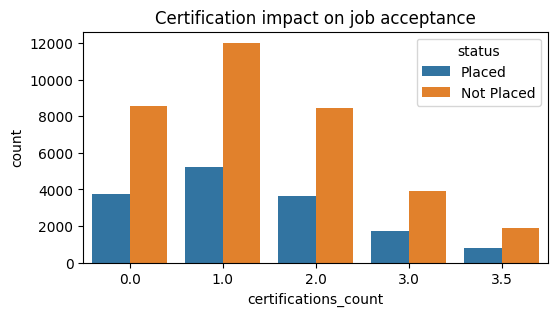

In [ ]:
# 3.Certification impact on job acceptance
plt.figure(figsize=(6,3))
plt.title('Certification impact on job acceptance')
sns.countplot(x='certifications_count',hue='status', data=df)
plt.show()

In [ ]:
#Insights:
#     1.This graph clearly shows,certifications have a positive impact on placement.
#     2.Highest number of placed persons are in 1 certification category.
#     3.second highest number of placed persons are in 2 certification category.
#     4.in all categories placed > not placed.

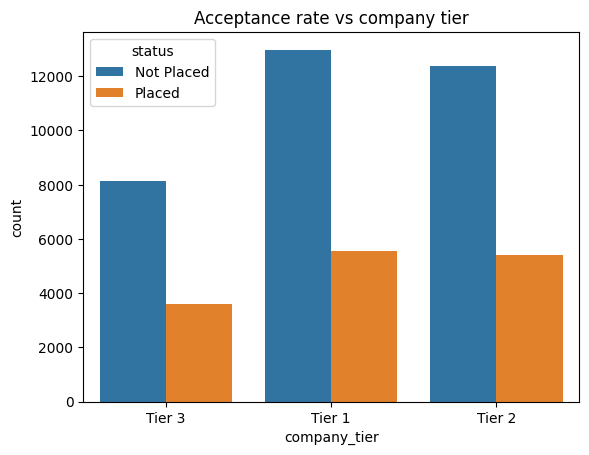

In [ ]:
# 4.Acceptance rate by company tier
plt.title('Acceptance rate vs company tier')
sns.countplot(x='company_tier', hue='status', data=df)
plt.show()

In [ ]:
#Insights:
#    1.This graph shows that,tier 3 comany has low acceptance rate.
#    2.Tier 2 and Tier 1 companies have more acceptance rate compared to tier 3 companies.


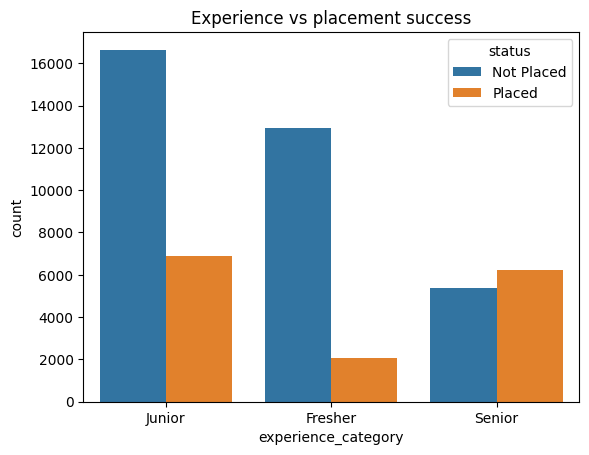

In [ ]:
# 5.Experience vs placement success
plt.title('Experience vs placement success')
sns.countplot(x='experience_category', hue='status', data=df)
plt.show()

In [ ]:
#Insights:
#     1.In this graph, we can clearly see that,  the junior candidates got more placement rate.
#     2.Next to junior candidates,senior persons have more placement success.
#     3.In fresher category,lack of experience affects placement.


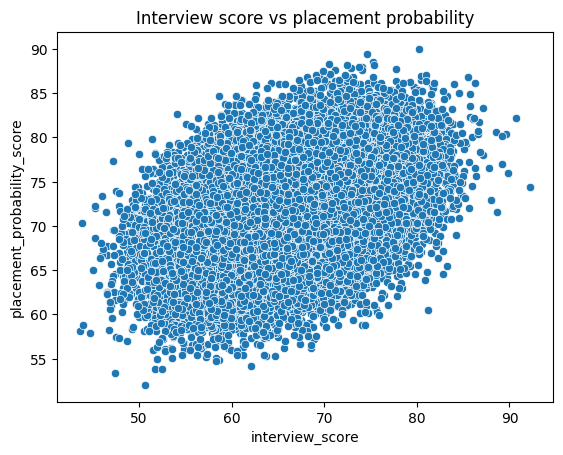

In [ ]:
# 6.Interview score vs placement probability

plt.title('Interview score vs placement probability')
sns.scatterplot(x='interview_score', y='placement_probability_score',data=df)
plt.show()

In [ ]:
#Insights:
#    1.There isna strong positive relationship,As interview score increases, placement probability also increases.
#    2.This means interview performance is a major factor in job selection.
#    3.Most candidates are clustered around,Interview score between 60–75.

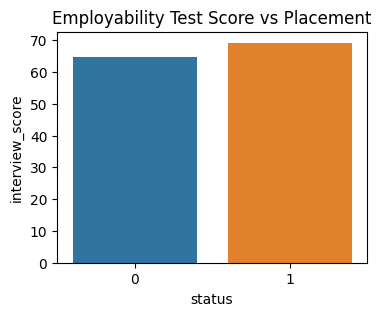

In [ ]:
# 7.Employability test score analysis
plt.figure(figsize=(4,3))
sns.barplot(x='status', y='interview_score', data=df, hue='status', legend=False)
plt.title("Employability Test Score vs Placement")
plt.show()


In [ ]:
#Insights:
#     1.As employability test score increases → chances of placement also increases.
#     2. It Shows a direct relationship between test performance and job acceptance.
#     3.It Indicates employability test performance strongly impacts placement.